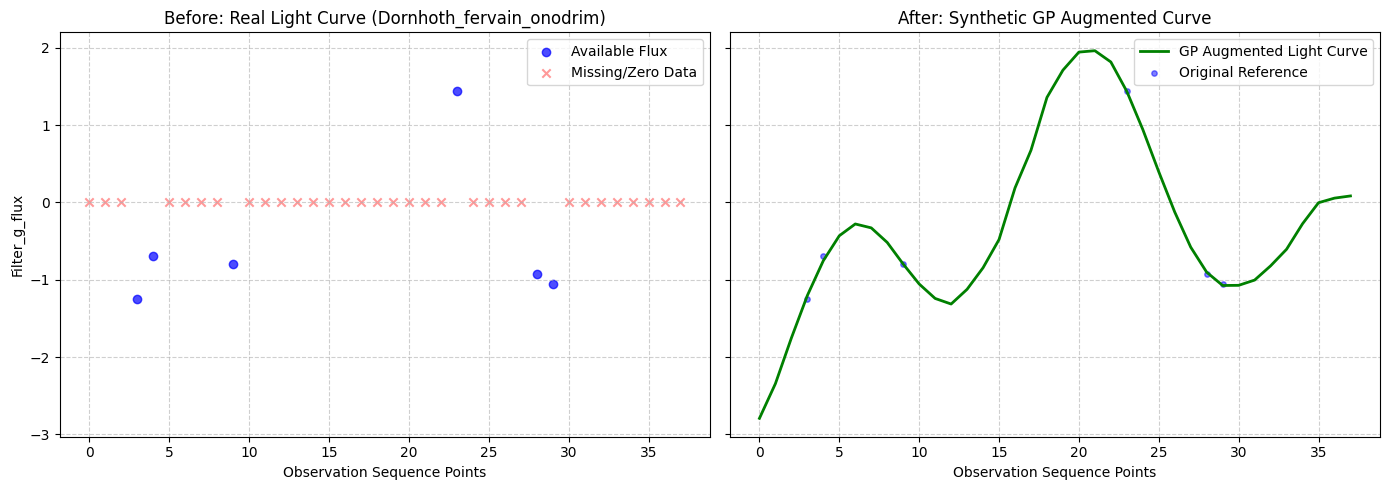

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
import pandas as pd
from pathlib import Path

# ==========================================
# 1. GP Augmentation Function
# ==========================================
def gp_multichannel_time_series_augment(X, y, n_aug=1, random_state=42, balance=False):
    rng = np.random.default_rng(random_state)
    N, T, C = X.shape
    X_new = []
    y_new = []

    kernel = RBF(length_scale=0.15, length_scale_bounds="fixed") + \
             WhiteKernel(noise_level=1e-3, noise_level_bounds="fixed")

    t_all = (np.arange(T) / T).reshape(-1, 1)

    for i in range(N):
        if balance and (y[i] != 1):
            continue
        x_orig = X[i]
        for _ in range(n_aug):
            x_syn = np.zeros_like(x_orig)
            for ch in range(C):
                flux = x_orig[:, ch]
                valid_idx = np.where(flux != 0)[0]
                if len(valid_idx) < 2:
                    continue
                t_valid = (valid_idx / T).reshape(-1, 1)
                y_valid = flux[valid_idx]
                gp = GaussianProcessRegressor(kernel=kernel, random_state=random_state, n_restarts_optimizer=0)
                gp.fit(t_valid, y_valid)
                pred, std = gp.predict(t_all, return_std=True)
                noise = rng.normal(0, 0.15 * std)
                x_syn[:, ch] = pred + noise
            X_new.append(x_syn)
            y_new.append(y[i])

    return np.stack(X_new), np.array(y_new)

# ==========================================
# 2. Extract Real CSV Sequence Data
# ==========================================
import os
location_of_file = f'{os.getcwd().replace("\\", "/")}/Data/Processed Data'

df = pd.read_csv(f"{location_of_file}/total_df.csv")
sequence = df[df["object_id"] == "Dornhoth_fervain_onodrim"][["Time (MJD)", "Filter_g_flux"]]
real_flux = sequence["Filter_g_flux"].to_numpy()

# Important: If your dataset represents gaps as NaNs, change them to 0 
# because your GP function looks specifically for 'flux != 0'
real_flux = np.nan_to_num(real_flux, nan=0.0)

# Get the length of this specific sequence
T = len(real_flux)  
C = 1               # 1 channel (Filter_g_flux)
N = 1               # 1 sample object

# Reshape the real sequence to match (N, T, C)
X_train = real_flux.reshape(N, T, C)
y_train = np.array([1])  # Dummy target label for this object

# ==========================================
# 3. Run the Augmentation Function
# ==========================================
X_aug, y_aug = gp_multichannel_time_series_augment(X_train, y_train, n_aug=1, random_state=42, balance=False)

# Extract 1D arrays for plotting
t_steps = np.arange(T)
# If you want to plot using actual MJD instead of step index, use:
# t_steps = sequence["Time (MJD)"].to_numpy()

original_curve = X_train[0, :, 0]
augmented_curve = X_aug[0, :, 0]

# ==========================================
# 4. Plot "Before" and "After" side-by-side
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot Before
valid_mask = original_curve != 0
axes[0].scatter(t_steps[valid_mask], original_curve[valid_mask], color='blue', label='Available Flux', alpha=0.7)
axes[0].scatter(t_steps[~valid_mask], original_curve[~valid_mask], color='red', marker='x', label='Missing/Zero Data', alpha=0.4)
axes[0].set_title("Before: Real Light Curve (Dornhoth_fervain_onodrim)")
axes[0].set_xlabel("Observation Sequence Points")
axes[0].set_ylabel("Filter_g_flux")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot After
axes[1].plot(t_steps, augmented_curve, color='green', linewidth=2, label='GP Augmented Light Curve')
axes[1].scatter(t_steps[valid_mask], original_curve[valid_mask], color='blue', s=15, label='Original Reference', alpha=0.5)
axes[1].set_title("After: Synthetic GP Augmented Curve")
axes[1].set_xlabel("Observation Sequence Points")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
directory = "D:/Senior Project/Mallorn version 2/Results/Plots"
plt.savefig(f'{directory}/Gaussian_augmentation_curve.png', bbox_inches='tight', dpi=300)
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

def gp_multichannel_time_series_augment(X, y, n_aug=1, random_state=42, balance=False):
    rng = np.random.default_rng(random_state)
    N, T, C = X.shape
    X_new = []
    y_new = []

    # FIX 1: Allow the optimizer to find the best fit, but guide it with realistic starting values.
    # We increase length_scale so it's smoother, and increase noise_level to handle the messiness.
    kernel = RBF(length_scale=0.3, length_scale_bounds=(0.1, 10)) + \
             WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-2, 1))

    t_all = (np.arange(T) / T).reshape(-1, 1)

    for i in range(N):
        if balance and (y[i] != 1):
            continue
        x_orig = X[i]
        for _ in range(n_aug):
            x_syn = np.zeros_like(x_orig)
            for ch in range(C):
                flux = x_orig[:, ch]
                valid_idx = np.where(flux != 0)[0]
                if len(valid_idx) < 2:
                    continue
                
                t_valid = (valid_idx / T).reshape(-1, 1)
                y_valid = flux[valid_idx]
                
                # FIX 2: Allowed n_restarts_optimizer=5 so it searches for the best smoothing fit
                gp = GaussianProcessRegressor(kernel=kernel, random_state=random_state, n_restarts_optimizer=5)
                gp.fit(t_valid, y_valid)
                
                pred, std = gp.predict(t_all, return_std=True)
                
                # The noise injected into the new sample is scaled by the GP's learned uncertainty
                noise = rng.normal(0, 0.15 * std)
                x_syn[:, ch] = pred + noise
                
            X_new.append(x_syn)
            y_new.append(y[i])

    return np.stack(X_new), np.array(y_new)

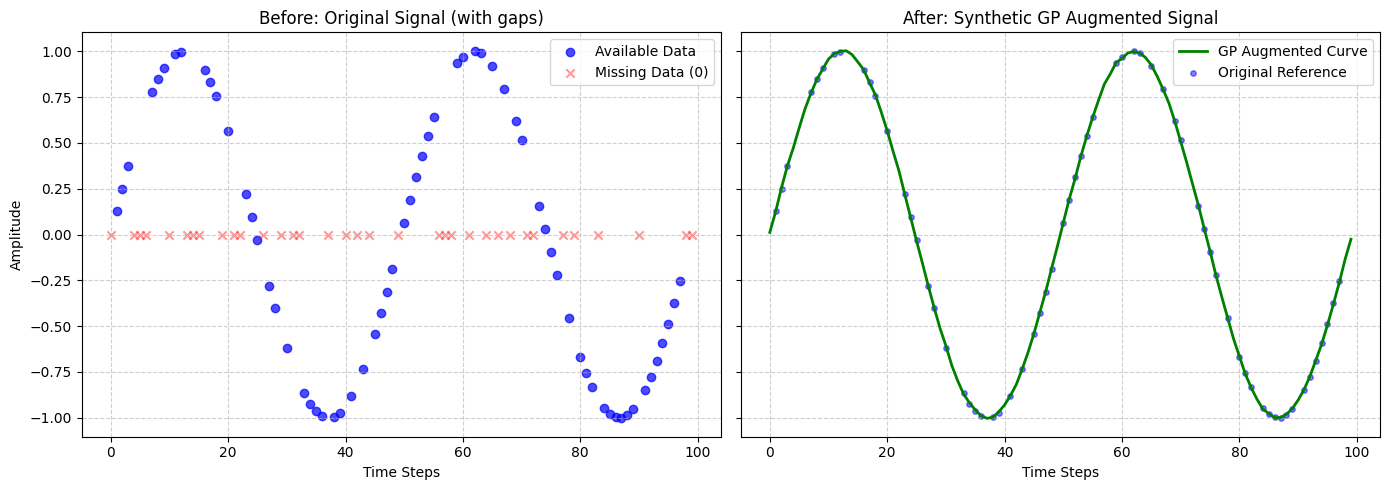

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# ==========================================
# 1. Paste your function here
# ==========================================
def GP_aug_new_version(X, y, n_aug=1, random_state=42, balance=False):
    rng = np.random.default_rng(random_state)
    N, T, C = X.shape
    X_new = []
    y_new = []

    kernel = RBF(length_scale=0.15, length_scale_bounds="fixed") + \
             WhiteKernel(noise_level=1e-3, noise_level_bounds="fixed")

    t_all = (np.arange(T) / T).reshape(-1, 1)

    for i in range(N):
        if balance and (y[i] != 1):
            continue
        x_orig = X[i]
        for _ in range(n_aug):
            x_syn = np.zeros_like(x_orig)
            for ch in range(C):
                flux = x_orig[:, ch]
                valid_idx = np.where(flux != 0)[0]
                if len(valid_idx) < 2:
                    continue
                t_valid = (valid_idx / T).reshape(-1, 1)
                y_valid = flux[valid_idx]
                gp = GaussianProcessRegressor(kernel=kernel, random_state=random_state, n_restarts_optimizer=0)
                gp.fit(t_valid, y_valid)
                pred, std = gp.predict(t_all, return_std=True)
                noise = rng.normal(0, 0.15 * std)
                x_syn[:, ch] = pred + noise
            X_new.append(x_syn)
            y_new.append(y[i])

    return np.stack(X_new), np.array(y_new)

# ==========================================
# 2. Generate Mock Training Data 
# ==========================================
np.random.seed(42)
T = 100  # 100 time steps
C = 1    # 1 channel (for easy plotting)
N = 1    # 1 sample

# Create a smooth sine wave curve
t = np.linspace(0, 4 * np.pi, T)
clean_signal = np.sin(t)

# Introduce some random missing data (setting them to 0 as your function expects)
mask = np.random.rand(T) > 0.3  # keep 70% of data
mock_sample = clean_signal.copy()
mock_sample[~mask] = 0.0

# Reshape to match your expected input shape (N, T, C)
X_train = mock_sample.reshape(N, T, C)
y_train = np.array([1])  # Class label 1

# ==========================================
# 3. Run the Augmentation Function
# ==========================================
# Generate 1 augmented version
X_aug, y_aug = GP_aug_new_version(X_train, y_train, n_aug=1, random_state=42, balance=False)

# Extract 1D arrays for plotting
t_steps = np.arange(T)
original_curve = X_train[0, :, 0]
augmented_curve = X_aug[0, :, 0]

# ==========================================
# 4. Plot "Before" and "After" side-by-side
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Plot Before
# Separate valid points from zero/missing points for visual clarity
valid_mask = original_curve != 0
axes[0].scatter(t_steps[valid_mask], original_curve[valid_mask], color='blue', label='Available Data', alpha=0.7)
axes[0].scatter(t_steps[~valid_mask], original_curve[~valid_mask], color='red', marker='x', label='Missing Data (0)', alpha=0.4)
axes[0].set_title("Before: Original Signal (with gaps)")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot After
axes[1].plot(t_steps, augmented_curve, color='green', linewidth=2, label='GP Augmented Curve')
axes[1].scatter(t_steps[valid_mask], original_curve[valid_mask], color='blue', s=15, label='Original Reference', alpha=0.5)
axes[1].set_title("After: Synthetic GP Augmented Signal")
axes[1].set_xlabel("Time Steps")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()